<a href="https://colab.research.google.com/github/ArchieJain120/ML_LAB/blob/main/1BM23CS049_LAB6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy: 0.73825

Confusion Matrix:
 [[158   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [ 62  91   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [ 27   0 120   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [ 42   1   0 118   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [103   0   0   0  48   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   1   0   2]
 [ 48   0   0   0   0 105   0   0   0   0   0   0   0   1   0   1   0   0
    0   0   0   0   0   0   0   0]
 [ 71   0   0   0   0   0  83   0   0   0   0   0   0   0   0   0   1   0
    0   0   0   0   0   0   0   0]
 [ 98   0   0   5   0   0   0  42   0   0   0   0   0   0   0   0   0   2
    0   0   0   0   0   0   0   0]
 [ 27   0   0   0   0   0   0   0 122   0   0   0   0   0   0   0   0   0
    0   0   0   

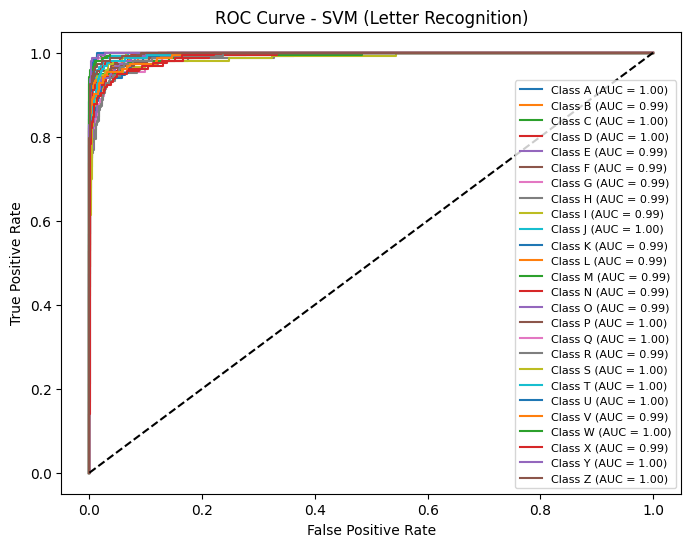


Average AUC: 0.9947411897580346


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.multiclass import OneVsRestClassifier

# =========================
# LOAD DATASET
# =========================

# Replace with your file name if different
data = pd.read_csv("/content/letter-recognition (1).csv")

# Features and target
X = data.iloc[:, 1:]   # assuming first column is letter label
y = data.iloc[:, 0]

# =========================
# ENCODE TARGET
# =========================

le = LabelEncoder()
y = le.fit_transform(y)

# =========================
# BINARIZE TARGET (for ROC)
# =========================

classes = np.unique(y)
y_bin = label_binarize(y, classes=classes)
n_classes = y_bin.shape[1]

# =========================
# TRAIN-TEST SPLIT (80/20)
# =========================

X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(
    X, y, y_bin, test_size=0.2, random_state=42, stratify=y
)

# =========================
# TRAIN SVM MODEL
# =========================

model = OneVsRestClassifier(SVC(kernel='rbf', probability=True))
model.fit(X_train, y_train_bin)

# =========================
# PREDICTIONS
# =========================

y_pred_bin = model.predict(X_test)
y_score = model.predict_proba(X_test)

# Convert binary predictions → class labels
y_pred = np.argmax(y_pred_bin, axis=1)
y_true = np.argmax(y_test_bin, axis=1)

# =========================
# EVALUATION
# =========================

print("Accuracy:", accuracy_score(y_true, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))

# =========================
# ROC CURVE + AUC
# =========================

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8,6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {le.inverse_transform([i])[0]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')  # diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM (Letter Recognition)")
plt.legend(loc="lower right", fontsize=8)
plt.show()

# Average AUC
print("\nAverage AUC:", np.mean(list(roc_auc.values())))